# Final Experiments — PID vs SMC Robustness to Marine Current

This notebook tests the limits of PID and SMC controllers when exposed to marine currents perturbations

## Experimental design

- All three axes (surge, sway, yaw) are controlled **simultaneously** in
  every run (`x_ref=0.9`, `y_ref=0.0`, `psi_ref=0.0`), rather than tested
  in isolation as during tuning. Under the decoupled model, this gives the
  same per-axis behavior as isolated tests while reflecting the actual
  deployment scenario.
- **Four current directions** are tested: 0°/180° (aligned with surge,
  opposing senses) and 90°/270° (aligned with sway, opposing senses).
- For each direction, current **magnitude is swept** from 0 up to and
  beyond the point where the PID controller is expected to fail.
- **Primary metric**: percentage of time spent within the 70–150 cm
  distance window — directly answers the research question.
- **Secondary metrics** (settling time, overshoot, steady-state error),
  computed only at a few representative magnitudes (not the full sweep),
  are used to explain *why* the primary metric changes — distinguishing
  oscillation, steady offset, and slow transients, which a single
  percentage cannot tell apart.

## Final gains used


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from offline_sim import run_simulation, distance_metrics, offset_metrics, full_metrics,chattering_metric

net_x = 2.0
d_ref = 1.1
x_ref = net_x - d_ref

gains_pid = dict(
    kp_u=7.5,  ki_u=0.65,  kd_u=11.0,  integral_max_u=25.0,
    kp_v=9.5,  ki_v=0.85,  kd_v=20.0,  integral_max_v=25.0,
    kp_r=0.44, ki_r=0.055, kd_r=0.49,  integral_max_r=1.0,
    tau_max_linear=60.0,
)

gains_smc = dict(
    lambda_u=0.5, k_u=3.55, phi_u=0.083,
    lambda_v=0.5, k_v=4.7,  phi_v=0.09,
    lambda_r=1.0, k_r=2.0,  phi_r=0.1,
    tau_max_linear=60.0,
)

**psi**: Verify once — known to hold for all directions.

**y**: Must be verified for each direction with a component along y (90°, 270°, and diagonals, if tested).
At 0°/180° it should remain flat at zero (no disturbance on that axis) — a good consistency check for that test.

## NO DISTURBANCE

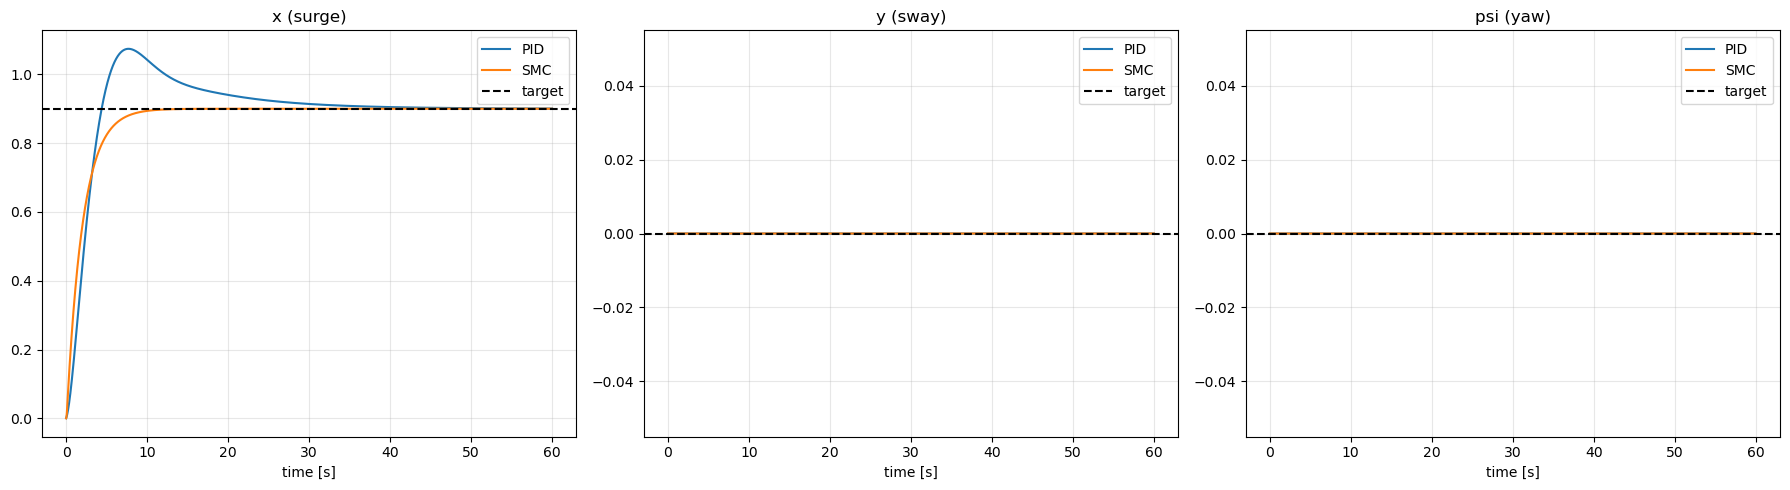

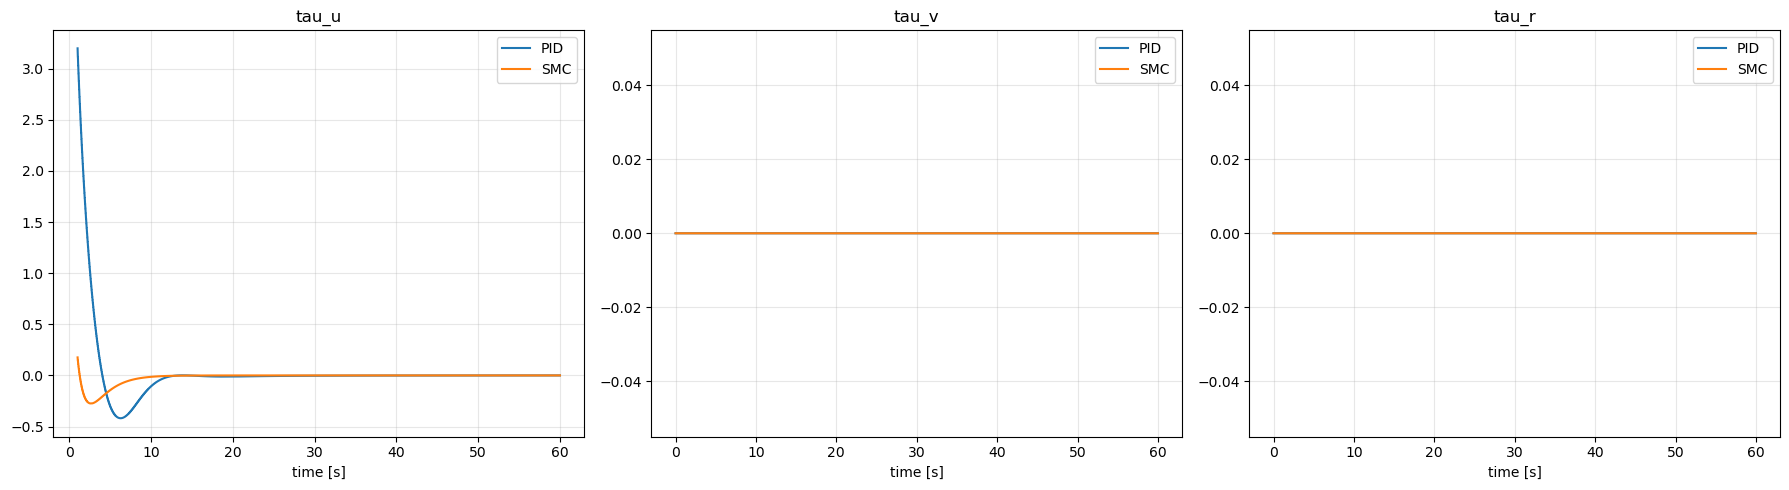

,controller,settling_x,overshoot_x,sse_x,settling_y,overshoot_y,sse_y,settling_psi,overshoot_psi,sse_psi,chatter_u,chatter_v,chatter_r
0,PID,18.87,19.3602,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SMC,6.05,0.0000,-0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
res_pid = run_simulation('pid', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                          current_magnitude=0.0, gains=gains_pid, duration=60.0)
res_smc = run_simulation('smc', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                          current_magnitude=0.0, gains=gains_smc, duration=60.0)

# --- Grafici di stato: x, y, psi -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(res_pid['t'], res_pid['x'], label='PID')
axes[0].plot(res_smc['t'], res_smc['x'], label='SMC')
axes[0].axhline(0.9, color='k', linestyle='--', label='target')
axes[0].set_title('x (surge)'); axes[0].set_xlabel('time [s]'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(res_pid['t'], res_pid['y'], label='PID')
axes[1].plot(res_smc['t'], res_smc['y'], label='SMC')
axes[1].axhline(0.0, color='k', linestyle='--', label='target')
axes[1].set_title('y (sway)'); axes[1].set_xlabel('time [s]'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(res_pid['t'], res_pid['psi'], label='PID')
axes[2].plot(res_smc['t'], res_smc['psi'], label='SMC')
axes[2].axhline(0.0, color='k', linestyle='--', label='target')
axes[2].set_title('psi (yaw)'); axes[2].set_xlabel('time [s]'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("no_current1.png", dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()

# --- Grafici dei comandi: tau_u, tau_v, tau_r -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mask = res_pid['t'] > 1.0
axes[0].plot(res_pid['t'][mask], res_pid['tau_u'][mask], label='PID')
axes[0].plot(res_smc['t'][mask], res_smc['tau_u'][mask], label='SMC')
axes[0].set_title('tau_u'); axes[0].set_xlabel('time [s]'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(res_pid['t'], res_pid['tau_v'], label='PID')
axes[1].plot(res_smc['t'], res_smc['tau_v'], label='SMC')
axes[1].set_title('tau_v'); axes[1].set_xlabel('time [s]'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(res_pid['t'], res_pid['tau_r'], label='PID')
axes[2].plot(res_smc['t'], res_smc['tau_r'], label='SMC')
axes[2].set_title('tau_r'); axes[2].set_xlabel('time [s]'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("no_current2.png", dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()

# --- Tabella metriche --------------------------------------------------------
rows = []
for name, res in [('PID', res_pid), ('SMC', res_smc)]:
    m_x = full_metrics(res, target=0.9, key='x')
    m_y = full_metrics(res, target=0.0, key='y')
    m_psi = full_metrics(res, target=0.0, key='psi')
    rows.append(dict(
        controller=name,
        settling_x=m_x['settling_time'], overshoot_x=m_x['overshoot_pct'], sse_x=m_x['steady_state_error'],
        settling_y=m_y['settling_time'], overshoot_y=m_y['overshoot_pct'], sse_y=m_y['steady_state_error'],
        settling_psi=m_psi['settling_time'], overshoot_psi=m_psi['overshoot_pct'], sse_psi=m_psi['steady_state_error'],
        chatter_u=chattering_metric(res, key='tau_u'),
        chatter_v=chattering_metric(res, key='tau_v'),
        chatter_r=chattering_metric(res, key='tau_r'),
    ))

df = pd.DataFrame(rows).round(4)
df


## What the plots show

**State plots (x, y)**: where the ROV is over time, compared to the
target (dashed line). They tell you WHETHER the controller reaches
the target and how long it takes. psi is not included: current never
affects it (no current term in r_dot), so there's nothing new to see
there compared to the zero-current case.

**Command plots (tau_u, tau_v)**: how much force the controller
requests over time, after the first second (the huge initial spike,
up to the 60N cap, is cut off so the rest is visible — this is
expected, it's the response to the large initial error). They tell
you HOW it gets there:
- with zero current, the curve should decay and flatten to **zero**
  (nothing to compensate at steady state)
- with current, a plateau near a **nonzero constant value** is
  expected: the controller is "working" to counteract the current
- fast oscillations instead of a smooth plateau indicate
  **chattering** (possible only with SMC, never with PID)

**Metrics table**: settling time (how long it takes to stabilize),
overshoot (how much it exceeds the target — % for target≠0, absolute
value for target=0), steady-state error (how far it remains from the
target at the end of the run), chattering rate on tau_u and tau_v —
for each axis and controller.

Note: if `current_direction_deg` is 0° or 180° (current aligned with
surge), sway receives no disturbance — y stays flat at zero; this is
correct, not a bug. Sway only "activates" with a current component
along y (90°, 270°, or diagonals).

## TESK WITH DISTRURBANCE
Here you can change the values of magnitude and direction to check correctness of all the following results

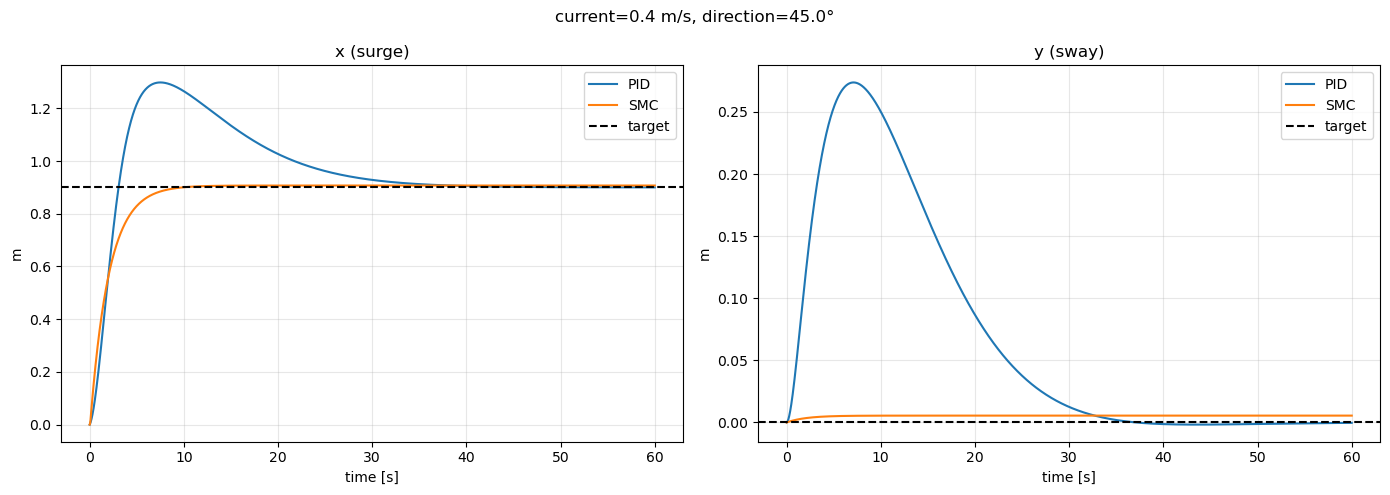

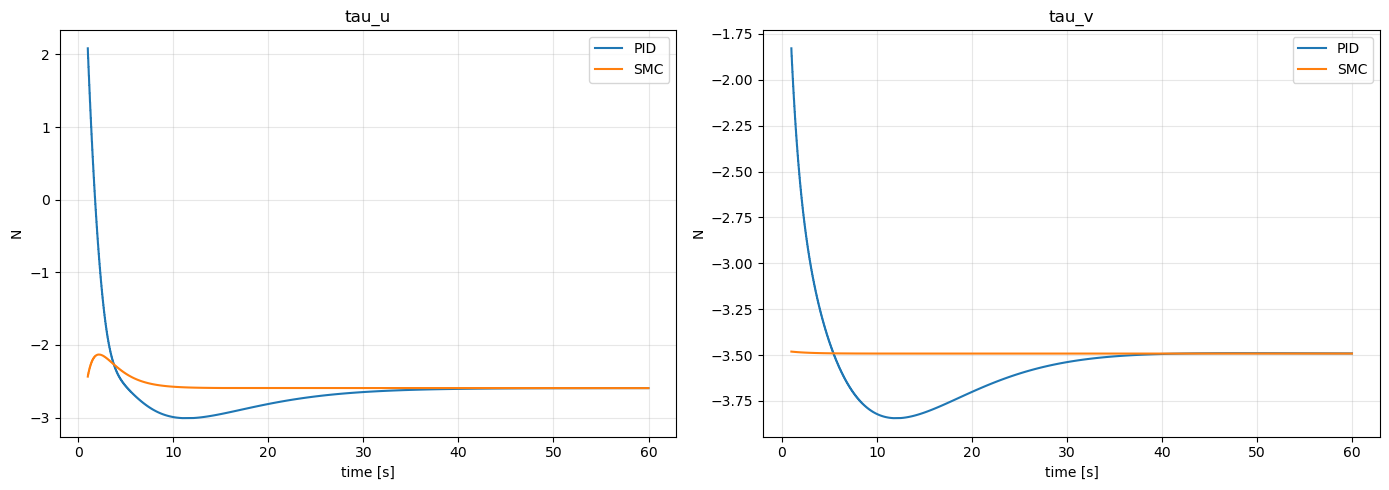

,controller,settling x [s],overshoot x [%],steady err x [m],settling y [s],overshoot y [m],steady err y [m],chattering u [Hz],chattering v [Hz]
0,PID,27.10,44.24,0.0004,23.43,0.2738,-0.0007,0.0,0.0
1,SMC,5.81,0.79,0.0071,0.00,0.0055,0.0055,0.0,0.0


In [14]:
# =============================================================================
# PARAMETRO DI CORRENTE -- modifica solo questi due valori per testare
# =============================================================================
current_magnitude = 0.4     # <-- cambia qui
current_direction_deg = 45.0 # <-- cambia qui (0=surge, 90=sway, 180, 270...)

# =============================================================================
# SIMULAZIONE
# =============================================================================
res_pid = run_simulation('pid', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                          current_magnitude=current_magnitude,
                          current_direction_deg=current_direction_deg,
                          gains=gains_pid, duration=60.0)
res_smc = run_simulation('smc', x_ref=0.9, y_ref=0.0, psi_ref=0.0,
                          current_magnitude=current_magnitude,
                          current_direction_deg=current_direction_deg,
                          gains=gains_smc, duration=60.0)

# =============================================================================
# GRAFICI DI STATO -- solo x e y (psi non serve, la corrente non lo tocca mai)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(res_pid['t'], res_pid['x'], label='PID')
axes[0].plot(res_smc['t'], res_smc['x'], label='SMC')
axes[0].axhline(0.9, color='k', linestyle='--', label='target')
axes[0].set_title('x (surge)'); axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('m')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(res_pid['t'], res_pid['y'], label='PID')
axes[1].plot(res_smc['t'], res_smc['y'], label='SMC')
axes[1].axhline(0.0, color='k', linestyle='--', label='target')
axes[1].set_title('y (sway)'); axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('m')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f'current={current_magnitude} m/s, direction={current_direction_deg}°')
plt.tight_layout()
plt.show()

# =============================================================================
# GRAFICI DI COMANDO -- solo tau_u e tau_v, esclude il primo secondo
# =============================================================================
mask_pid = res_pid['t'] > 1.0
mask_smc = res_smc['t'] > 1.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(res_pid['t'][mask_pid], res_pid['tau_u'][mask_pid], label='PID')
axes[0].plot(res_smc['t'][mask_smc], res_smc['tau_u'][mask_smc], label='SMC')
axes[0].set_title('tau_u'); axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('N')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(res_pid['t'][mask_pid], res_pid['tau_v'][mask_pid], label='PID')
axes[1].plot(res_smc['t'][mask_smc], res_smc['tau_v'][mask_smc], label='SMC')
axes[1].set_title('tau_v'); axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('N')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# TABELLA METRICHE -- con unità di misura esplicite
# =============================================================================
import pandas as pd

rows = []
for name, res in [('PID', res_pid), ('SMC', res_smc)]:
    m_x = full_metrics(res, target=0.9, key='x')
    m_y = full_metrics(res, target=0.0, key='y')
    rows.append(dict(
        controller=name,
        **{'settling x [s]': m_x['settling_time'],
           'overshoot x [%]': round(m_x['overshoot_pct'], 2),
           'steady err x [m]': round(m_x['steady_state_error'], 4),
           'settling y [s]': m_y['settling_time'],
           'overshoot y [m]': round(m_y['overshoot_pct'], 4),
           'steady err y [m]': round(m_y['steady_state_error'], 4),
           'chattering u [Hz]': round(chattering_metric(res, key='tau_u'), 2),
           'chattering v [Hz]': round(chattering_metric(res, key='tau_v'), 2)}
    ))

df = pd.DataFrame(rows)
df


In [4]:
def sweep_current(controller_type, gains, direction_deg, magnitudes,
                   x_ref=0.9, y_ref=0.0, psi_ref=0.0, duration=60.0,
                   target=0.9, key='x', tolerance=0.10):
    """
    Esegue run_simulation per ogni magnitudine di corrente data una
    direzione fissa, per un asse specifico (key='x'/'y'/'psi').
    Restituisce un dizionario con tutte le metriche.
    """
    out = dict(pct=[], settling_time=[], overshoot=[], steady_state_error=[],
               chattering=[], max_tau=[])
    tau_key = {'x': 'tau_u', 'y': 'tau_v', 'psi': 'tau_r'}[key]

    for mag in magnitudes:
        res = run_simulation(controller_type, x_ref=x_ref, y_ref=y_ref, psi_ref=psi_ref,
                              current_magnitude=mag, current_direction_deg=direction_deg,
                              gains=gains, duration=duration)

        if key == 'x':
            pct = distance_metrics(res, net_x=net_x)['pct_in_window']
        else:
            pct = offset_metrics(res, target=target, key=key, tolerance=tolerance)

        fm = full_metrics(res, target=target, key=key)
        chatter = chattering_metric(res, key=tau_key)
        mask = res['t'] > 0.5
        max_tau = np.abs(res[tau_key][mask]).max()

        out['pct'].append(pct)
        out['settling_time'].append(fm['settling_time'])
        out['overshoot'].append(fm['overshoot_pct'])
        out['steady_state_error'].append(fm['steady_state_error'])
        out['chattering'].append(chatter)
        out['max_tau'].append(max_tau)

    return {k: np.array(v, dtype=float) for k, v in out.items()}

## PERCENTAGE OF TIME IN THE WINDOW

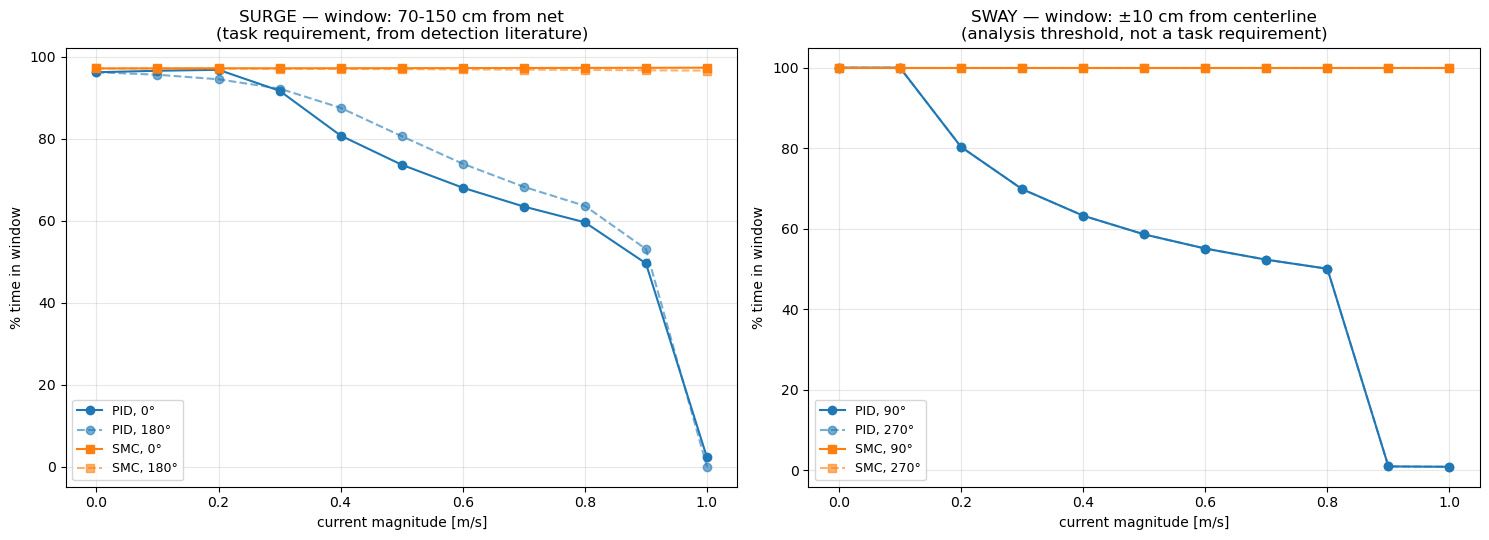

In [5]:
magnitudes = np.arange(0.0, 1.05, 0.1)   # griglia, poi eventualmente infittita

# --- Surge: direzioni 0° e 180° -----------------------------------------------
pct_pid_surge_0 = sweep_current('pid', gains_pid, direction_deg=0.0, magnitudes=magnitudes,
                                 target=0.9, key='x')['pct']
pct_smc_surge_0 = sweep_current('smc', gains_smc, direction_deg=0.0, magnitudes=magnitudes,
                                 target=0.9, key='x')['pct']
pct_pid_surge_180 = sweep_current('pid', gains_pid, direction_deg=180.0, magnitudes=magnitudes,
                                   target=0.9, key='x')['pct']
pct_smc_surge_180 = sweep_current('smc', gains_smc, direction_deg=180.0, magnitudes=magnitudes,
                                   target=0.9, key='x')['pct']

# --- Sway: dirbezioni 90° e 270° -----------------------------------------------
pct_pid_sway_90 = sweep_current('pid', gains_pid, direction_deg=90.0, magnitudes=magnitudes,
                                 target=0.0, key='y', tolerance=0.10)['pct']
pct_smc_sway_90 = sweep_current('smc', gains_smc, direction_deg=90.0, magnitudes=magnitudes,
                                 target=0.0, key='y', tolerance=0.10)['pct']
pct_pid_sway_270 = sweep_current('pid', gains_pid, direction_deg=270.0, magnitudes=magnitudes,
                                  target=0.0, key='y', tolerance=0.10)['pct']
pct_smc_sway_270 = sweep_current('smc', gains_smc, direction_deg=270.0, magnitudes=magnitudes,
                                  target=0.0, key='y', tolerance=0.10)['pct']

# --- Grafici, con le finestre esplicite nel titolo ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(magnitudes, pct_pid_surge_0, 'o-', color='tab:blue', label='PID, 0°')
axes[0].plot(magnitudes, pct_pid_surge_180, 'o--', color='tab:blue', alpha=0.6, label='PID, 180°')
axes[0].plot(magnitudes, pct_smc_surge_0, 's-', color='tab:orange', label='SMC, 0°')
axes[0].plot(magnitudes, pct_smc_surge_180, 's--', color='tab:orange', alpha=0.6, label='SMC, 180°')
axes[0].set_xlabel('current magnitude [m/s]')
axes[0].set_ylabel('% time in window')
axes[0].set_title('SURGE — window: 70-150 cm from net\n(task requirement, from detection literature)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(magnitudes, pct_pid_sway_90, 'o-', color='tab:blue', label='PID, 90°')
axes[1].plot(magnitudes, pct_pid_sway_270, 'o--', color='tab:blue', alpha=0.6, label='PID, 270°')
axes[1].plot(magnitudes, pct_smc_sway_90, 's-', color='tab:orange', label='SMC, 90°')
axes[1].plot(magnitudes, pct_smc_sway_270, 's--', color='tab:orange', alpha=0.6, label='SMC, 270°')
axes[1].set_xlabel('current magnitude [m/s]')
axes[1].set_ylabel('% time in window')
axes[1].set_title('SWAY — window: ±10 cm from centerline\n(analysis threshold, not a task requirement)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("percentageinwindow.png", dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()

## Percentage of time in window vs current

**SURGE** (window: 70–150 cm from net, task requirement): PID keeps ~95% time-in-window
up to ~0.2 m/s current, then degrades steadily as current increases, dropping to
near 0% at 1.0 m/s. SMC stays essentially flat at ~98% across the whole current
range, regardless of direction (0° or 180°) — it fully rejects surge-aligned current.

**SWAY** (window: ±10 cm from centerline, analysis threshold only): PID starts at
100% with no current, then drops steadily as current magnitude increases (90°/270°),
falling to near 0% by 1.0 m/s. SMC again stays flat at 100% across all magnitudes
and directions tested.

**Takeaway**: SMC is robust to current disturbances on both axes and directions
tested, while PID's performance degrades roughly monotonically with current
magnitude, on both surge (task-critical) and sway (secondary threshold).

## FINAL STATE ERROR

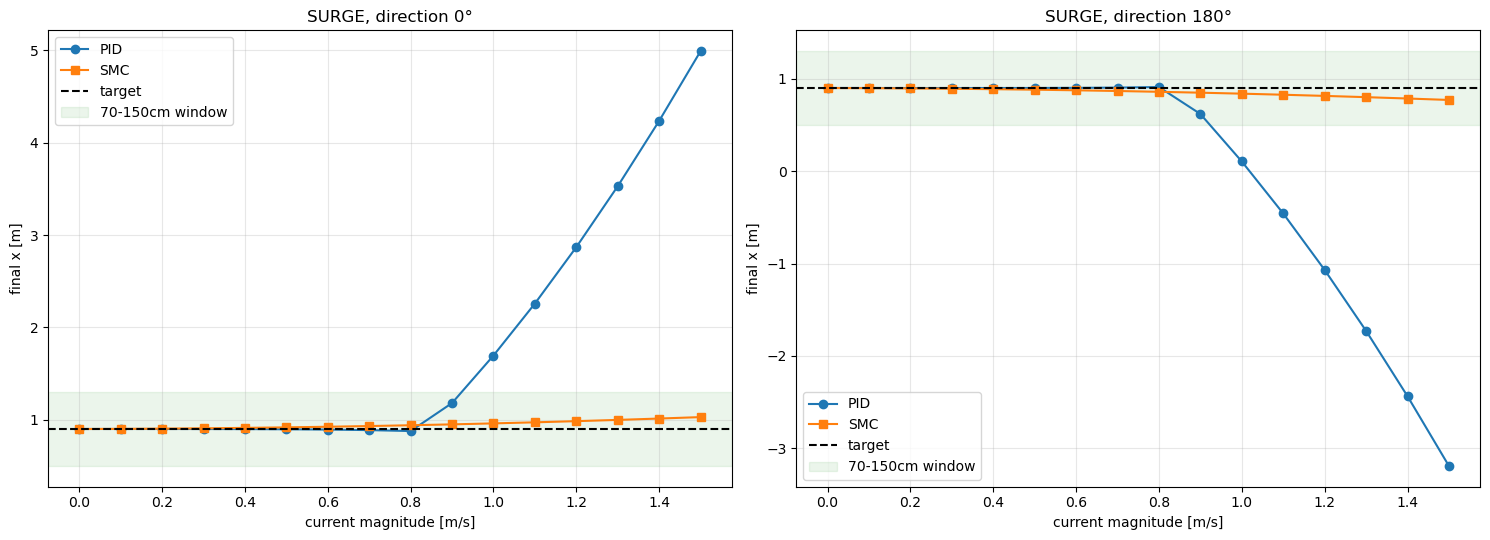

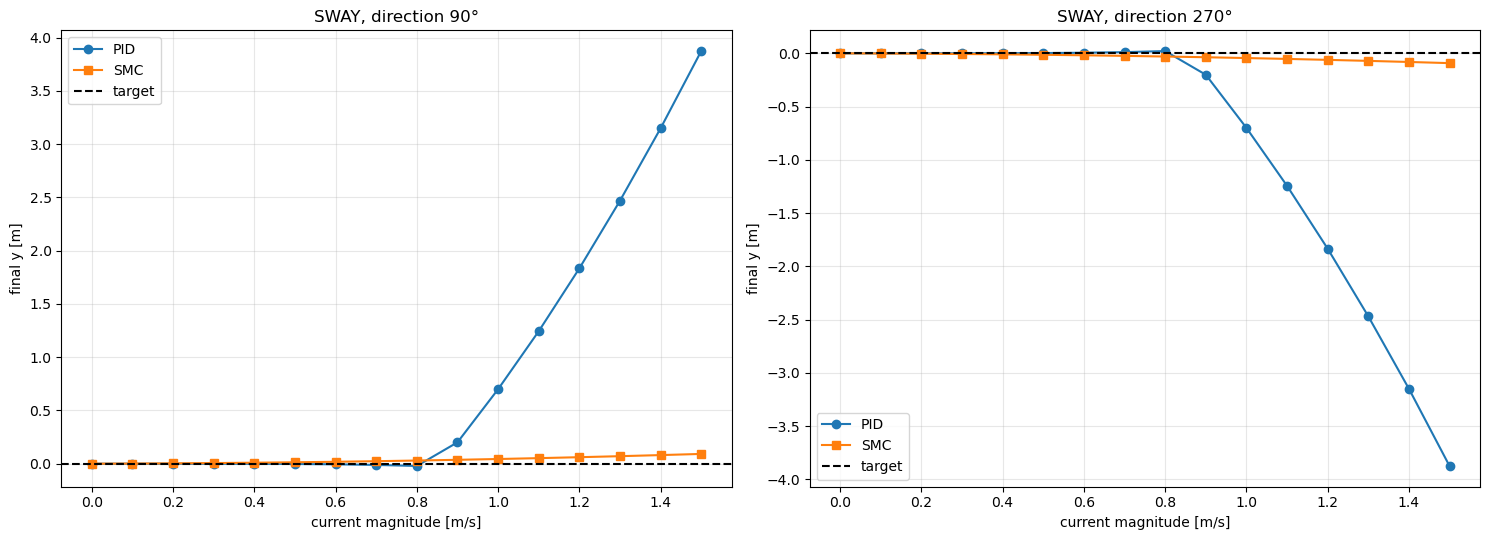

In [6]:
magnitudes_fine = np.arange(0.0, 1.55, 0.1)

def sweep_final_state(controller_type, gains, direction_deg, magnitudes,
                       x_ref=0.9, y_ref=0.0, psi_ref=0.0, key='x', duration=60.0):
    """Ritorna il valore finale (a fine simulazione) dello stato scelto,
    per ogni magnitudine di corrente."""
    finals = []
    for mag in magnitudes:
        res = run_simulation(controller_type, x_ref=x_ref, y_ref=y_ref, psi_ref=psi_ref,
                              current_magnitude=mag, current_direction_deg=direction_deg,
                              gains=gains, duration=duration)
        finals.append(res[key][-1])
    return np.array(finals)


# --- SURGE: 0° e 180° ---------------------------------------------------------
x_final_pid_0   = sweep_final_state('pid', gains_pid, 0.0,   magnitudes_fine, key='x')
x_final_smc_0   = sweep_final_state('smc', gains_smc, 0.0,   magnitudes_fine, key='x')
x_final_pid_180 = sweep_final_state('pid', gains_pid, 180.0, magnitudes_fine, key='x')
x_final_smc_180 = sweep_final_state('smc', gains_smc, 180.0, magnitudes_fine, key='x')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(magnitudes_fine, x_final_pid_0, 'o-', label='PID')
axes[0].plot(magnitudes_fine, x_final_smc_0, 's-', label='SMC')
axes[0].axhline(0.9, color='k', linestyle='--', label='target')
axes[0].axhspan(2.0-1.50, 2.0-0.70, color='green', alpha=0.08, label='70-150cm window')
axes[0].set_xlabel('current magnitude [m/s]'); axes[0].set_ylabel('final x [m]')
axes[0].set_title('SURGE, direction 0°'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(magnitudes_fine, x_final_pid_180, 'o-', label='PID')
axes[1].plot(magnitudes_fine, x_final_smc_180, 's-', label='SMC')
axes[1].axhline(0.9, color='k', linestyle='--', label='target')
axes[1].axhspan(2.0-1.50, 2.0-0.70, color='green', alpha=0.08, label='70-150cm window')
axes[1].set_xlabel('current magnitude [m/s]'); axes[1].set_ylabel('final x [m]')
axes[1].set_title('SURGE, direction 180°'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("finalstateerror1.png",dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()


# --- SWAY: 90° e 270° ---------------------------------------------------------
y_final_pid_90  = sweep_final_state('pid', gains_pid, 90.0,  magnitudes_fine, key='y')
y_final_smc_90  = sweep_final_state('smc', gains_smc, 90.0,  magnitudes_fine, key='y')
y_final_pid_270 = sweep_final_state('pid', gains_pid, 270.0, magnitudes_fine, key='y')
y_final_smc_270 = sweep_final_state('smc', gains_smc, 270.0, magnitudes_fine, key='y')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(magnitudes_fine, y_final_pid_90, 'o-', label='PID')
axes[0].plot(magnitudes_fine, y_final_smc_90, 's-', label='SMC')
axes[0].axhline(0.0, color='k', linestyle='--', label='target')
axes[0].set_xlabel('current magnitude [m/s]'); axes[0].set_ylabel('final y [m]')
axes[0].set_title('SWAY, direction 90°'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(magnitudes_fine, y_final_pid_270, 'o-', label='PID')
axes[1].plot(magnitudes_fine, y_final_smc_270, 's-', label='SMC')
axes[1].axhline(0.0, color='k', linestyle='--', label='target')
axes[1].set_xlabel('current magnitude [m/s]'); axes[1].set_ylabel('final y [m]')
axes[1].set_title('SWAY, direction 270°'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("finalstateerror2.png", dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()

These plots show the **final x/y position** at the end of each simulation (steady-state
outcome), rather than time-in-window — so they reveal *how far* the vehicle ends up
from the target as current increases.

**SURGE (0°, 180°)**: PID's final x diverges roughly linearly with current magnitude
once above ~0.7–0.8 m/s, moving several meters away from the target and out of the
70–150 cm window entirely by 1.5 m/s. SMC stays essentially locked to the target
across almost the whole range, with only a small, bounded deviation appearing at the
highest magnitudes (>1.3 m/s) — still well inside the acceptable window.

**SWAY (90°, 270°)**: same pattern — PID's final y grows unbounded with current
magnitude (up to ~±4 m at 1.5 m/s), while SMC remains close to zero throughout, with
a comparably small drift only at the extreme end of the tested range.

**Takeaway**: PID has no steady-state disturbance rejection — the final position
error scales with current strength. SMC maintains near-zero steady-state error over
the whole tested range, confirming its robustness even at current magnitudes beyond
the original 0–1.0 m/s sweep.

## TRUSTERS COMMANDS AND CHATTERING

**Peak thrust plots (tau_u, tau_v)**: maximum commanded force after the initial
transient (t > 0.5 s), for each controller/direction, as current magnitude
increases. Both PID and SMC show peak thrust growing roughly quadratically with
current magnitude, as expected — stronger currents require more force to
counteract. SMC reaches the `tau_max` = 60 N saturation limit earlier than PID
(around 1.3–1.4 m/s vs PID staying below it up to 1.5 m/s), reflecting SMC's
more aggressive control action needed to maintain near-zero steady-state error.
Direction (0°/180° for surge, 90°/270° for sway) has little effect on the trend.

**Chattering plots (SMC only)**: switching rate on the control signal.
For surge, chattering stays at zero across the entire current range — no
switching behavior appears. For sway, chattering is also zero almost everywhere,
with a single sharp spike (~0.033 switch/s) at 90° around 1.3 m/s — an isolated
occurrence rather than a persistent trend, likely tied to the controller
approaching saturation at that specific point.

**Takeaway**: SMC pays for its robustness with higher peak thrust demand,
saturating sooner than PID as current increases, while chattering remains
negligible overall — with one isolated exception near saturation at high sway
current.

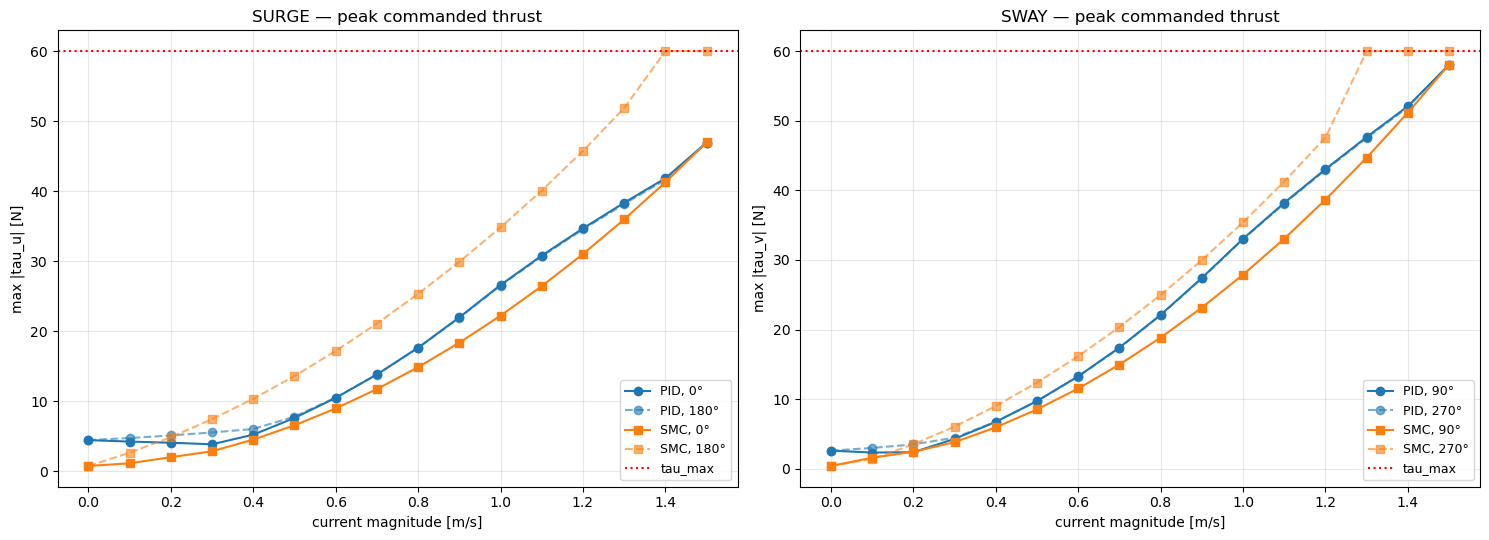

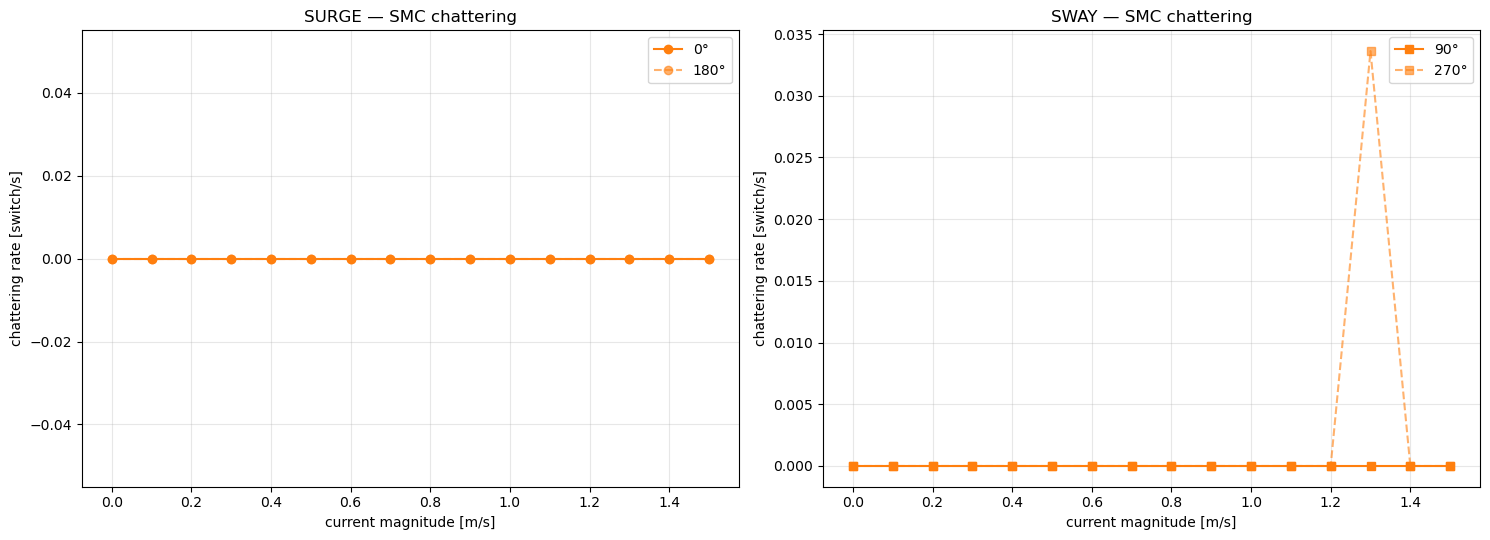

In [7]:
def sweep_max_tau(controller_type, gains, direction_deg, magnitudes,
                   x_ref=0.9, y_ref=0.0, psi_ref=0.0, tau_key='tau_u', duration=60.0):
    maxes = []
    for mag in magnitudes:
        res = run_simulation(controller_type, x_ref=x_ref, y_ref=y_ref, psi_ref=psi_ref,
                              current_magnitude=mag, current_direction_deg=direction_deg,
                              gains=gains, duration=duration)
        mask = res['t'] > 0.5
        maxes.append(np.abs(res[tau_key][mask]).max())
    return np.array(maxes)


def sweep_chattering(controller_type, gains, direction_deg, magnitudes,
                      x_ref=0.9, y_ref=0.0, psi_ref=0.0, tau_key='tau_u', duration=60.0):
    rates = []
    for mag in magnitudes:
        res = run_simulation(controller_type, x_ref=x_ref, y_ref=y_ref, psi_ref=psi_ref,
                              current_magnitude=mag, current_direction_deg=direction_deg,
                              gains=gains, duration=duration)
        rates.append(chattering_metric(res, key=tau_key))
    return np.array(rates)


# =============================================================================
# GRAFICO 5 -- saturazione: SURGE (0°, 180°) e SWAY (90°, 270°)
# =============================================================================
max_tau_pid_0   = sweep_max_tau('pid', gains_pid, 0.0,   magnitudes_fine, tau_key='tau_u')
max_tau_smc_0   = sweep_max_tau('smc', gains_smc, 0.0,   magnitudes_fine, tau_key='tau_u')
max_tau_pid_180 = sweep_max_tau('pid', gains_pid, 180.0, magnitudes_fine, tau_key='tau_u')
max_tau_smc_180 = sweep_max_tau('smc', gains_smc, 180.0, magnitudes_fine, tau_key='tau_u')

max_tau_pid_90  = sweep_max_tau('pid', gains_pid, 90.0,  magnitudes_fine, x_ref=0.0, y_ref=0.5, tau_key='tau_v')
max_tau_smc_90  = sweep_max_tau('smc', gains_smc, 90.0,  magnitudes_fine, x_ref=0.0, y_ref=0.5, tau_key='tau_v')
max_tau_pid_270 = sweep_max_tau('pid', gains_pid, 270.0, magnitudes_fine, x_ref=0.0, y_ref=0.5, tau_key='tau_v')
max_tau_smc_270 = sweep_max_tau('smc', gains_smc, 270.0, magnitudes_fine, x_ref=0.0, y_ref=0.5, tau_key='tau_v')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(magnitudes_fine, max_tau_pid_0,   'o-',  color='tab:blue',   label='PID, 0°')
axes[0].plot(magnitudes_fine, max_tau_pid_180, 'o--', color='tab:blue',   alpha=0.6, label='PID, 180°')
axes[0].plot(magnitudes_fine, max_tau_smc_0,   's-',  color='tab:orange', label='SMC, 0°')
axes[0].plot(magnitudes_fine, max_tau_smc_180, 's--', color='tab:orange', alpha=0.6, label='SMC, 180°')
axes[0].axhline(60, color='r', linestyle=':', label='tau_max')
axes[0].set_xlabel('current magnitude [m/s]'); axes[0].set_ylabel('max |tau_u| [N]')
axes[0].set_title('SURGE — peak commanded thrust'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(magnitudes_fine, max_tau_pid_90,  'o-',  color='tab:blue',   label='PID, 90°')
axes[1].plot(magnitudes_fine, max_tau_pid_270, 'o--', color='tab:blue',   alpha=0.6, label='PID, 270°')
axes[1].plot(magnitudes_fine, max_tau_smc_90,  's-',  color='tab:orange', label='SMC, 90°')
axes[1].plot(magnitudes_fine, max_tau_smc_270, 's--', color='tab:orange', alpha=0.6, label='SMC, 270°')
axes[1].axhline(60, color='r', linestyle=':', label='tau_max')
axes[1].set_xlabel('current magnitude [m/s]'); axes[1].set_ylabel('max |tau_v| [N]')
axes[1].set_title('SWAY — peak commanded thrust'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("trusters.png", dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()


# =============================================================================
# GRAFICO 6 -- chattering (solo SMC): SURGE (0°, 180°) e SWAY (90°, 270°)
# =============================================================================
chatter_smc_0   = sweep_chattering('smc', gains_smc, 0.0,   magnitudes_fine, tau_key='tau_u')
chatter_smc_180 = sweep_chattering('smc', gains_smc, 180.0, magnitudes_fine, tau_key='tau_u')
chatter_smc_90  = sweep_chattering('smc', gains_smc, 90.0,  magnitudes_fine, x_ref=0.0, y_ref=0.5, tau_key='tau_v')
chatter_smc_270 = sweep_chattering('smc', gains_smc, 270.0, magnitudes_fine, x_ref=0.0, y_ref=0.5, tau_key='tau_v')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(magnitudes_fine, chatter_smc_0,   'o-',  color='tab:orange', label='0°')
axes[0].plot(magnitudes_fine, chatter_smc_180, 'o--', color='tab:orange', alpha=0.6, label='180°')
axes[0].set_xlabel('current magnitude [m/s]'); axes[0].set_ylabel('chattering rate [switch/s]')
axes[0].set_title('SURGE — SMC chattering'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(magnitudes_fine, chatter_smc_90,  's-',  color='tab:orange', label='90°')
axes[1].plot(magnitudes_fine, chatter_smc_270, 's--', color='tab:orange', alpha=0.6, label='270°')
axes[1].set_xlabel('current magnitude [m/s]'); axes[1].set_ylabel('chattering rate [switch/s]')
axes[1].set_title('SWAY — SMC chattering'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("chattering.png", dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()

The chattering spike appears only near 1.3 m/s because this is the transition
boundary between the two regimes: below it SMC tracks with margin (smooth,
non-saturated command), above it the command stays pinned at the 60 N
saturation limit (also no switching). Right at the boundary, the sliding
surface hovers near the point where the discontinuous switching term is just
barely sufficient to reject the current, causing rapid back-and-forth
switching between saturated and non-saturated — the textbook signature of
chattering occurring at the edge of the actuator's authority.

## How far can SMC be pushed?

Extending the current sweep to extreme magnitudes (up to 5.0 m/s) exposes the
actuator limits of SMC:

**Final position**: SMC tracks the target almost perfectly up to ~1.0–1.3 m/s,
then diverges sharply once the required control effort exceeds what the
thrusters can deliver — final x/y grow to hundreds of meters, confirming a
complete loss of control authority rather than a graceful degradation.

**Peak thrust**: saturates at `tau_max` = 60 N around 1.3–1.5 m/s (both surge
and sway, both directions) and stays pinned there for the rest of the range —
the controller is demanding more force than the actuators can physically
produce.

**Chattering**: drops to zero once saturation is reached. This is expected,
not a bug: chattering measures switching in the control signal, but once
tau is clamped at a constant saturation value there is nothing left to
switch between — the metric can only be meaningful in the pre-saturation
regime.

**Takeaway**: SMC's robustness holds only within the actuator's force
envelope. Beyond ~1.3 m/s of current (well outside the realistic 0–1.0 m/s
range for this task), the controller saturates and the vehicle loses the
ability to hold position entirely — this is an actuator limitation, not a
control-law failure.

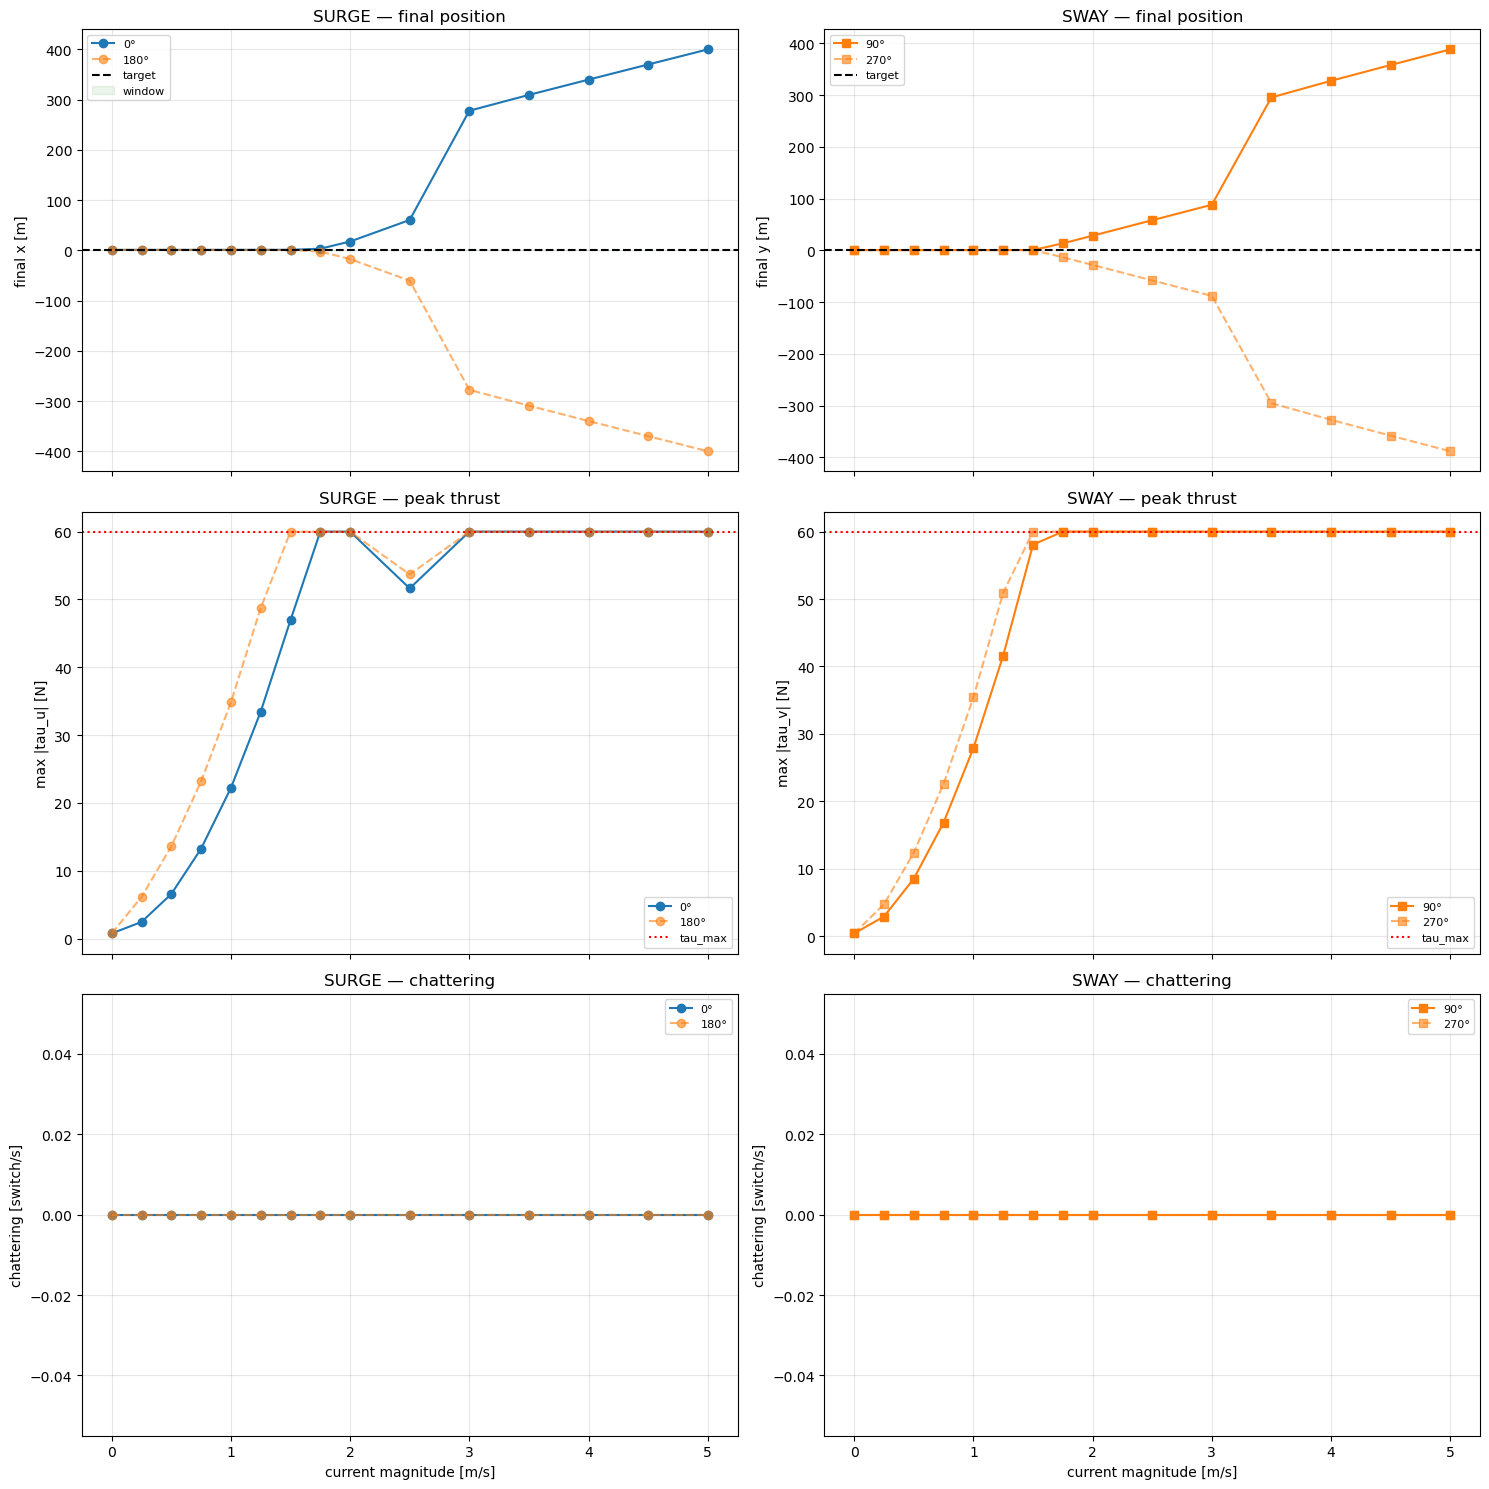


=== 0° (surge) ===
0.00 m/s -> final:    0.900  max_tau:    0.7  chattering:    0.0
0.25 m/s -> final:    0.906  max_tau:    2.4  chattering:    0.0
0.50 m/s -> final:    0.918  max_tau:    6.6  chattering:    0.0
0.75 m/s -> final:    0.936  max_tau:   13.2  chattering:    0.0
1.00 m/s -> final:    0.961  max_tau:   22.2  chattering:    0.0
1.25 m/s -> final:    0.992  max_tau:   33.4  chattering:    0.0
1.50 m/s -> final:    1.029  max_tau:   46.9  chattering:    0.0
1.75 m/s -> final:    3.210  max_tau:   60.0  chattering:    0.0
2.00 m/s -> final:   17.571  max_tau:   60.0  chattering:    0.0
2.50 m/s -> final:   60.422  max_tau:   51.6  chattering:    0.0
3.00 m/s -> final:  277.761  max_tau:   60.0  chattering:    0.0
3.50 m/s -> final:  309.252  max_tau:   60.0  chattering:    0.0
4.00 m/s -> final:  339.641  max_tau:   60.0  chattering:    0.0
4.50 m/s -> final:  369.735  max_tau:   60.0  chattering:    0.0
5.00 m/s -> final:  399.741  max_tau:   60.0  chattering:    0.0

=== 

In [8]:
magnitudes_extreme = np.concatenate([
    np.arange(0.0, 2.0, 0.25),
    np.arange(2.0, 5.5, 0.5),
])

# --- SURGE: 0° e 180° ---------------------------------------------------------
x_final_smc_0   = sweep_final_state('smc', gains_smc, 0.0,   magnitudes_extreme, key='x')
x_final_smc_180 = sweep_final_state('smc', gains_smc, 180.0, magnitudes_extreme, key='x')
max_tau_smc_0   = sweep_max_tau('smc', gains_smc, 0.0,   magnitudes_extreme, tau_key='tau_u')
max_tau_smc_180 = sweep_max_tau('smc', gains_smc, 180.0, magnitudes_extreme, tau_key='tau_u')
chatter_smc_0   = sweep_chattering('smc', gains_smc, 0.0,   magnitudes_extreme, tau_key='tau_u')
chatter_smc_180 = sweep_chattering('smc', gains_smc, 180.0, magnitudes_extreme, tau_key='tau_u')

# --- SWAY: 90° e 270° ----------------------------------------------------------
x_final_smc_90  = sweep_final_state('smc', gains_smc, 90.0,  magnitudes_extreme, x_ref=0.0, y_ref=0.5, key='y')
x_final_smc_270 = sweep_final_state('smc', gains_smc, 270.0, magnitudes_extreme, x_ref=0.0, y_ref=0.5, key='y')
max_tau_smc_90  = sweep_max_tau('smc', gains_smc, 90.0,  magnitudes_extreme, x_ref=0.0, y_ref=0.5, tau_key='tau_v')
max_tau_smc_270 = sweep_max_tau('smc', gains_smc, 270.0, magnitudes_extreme, x_ref=0.0, y_ref=0.5, tau_key='tau_v')
chatter_smc_90  = sweep_chattering('smc', gains_smc, 90.0,  magnitudes_extreme, x_ref=0.0, y_ref=0.5, tau_key='tau_v')
chatter_smc_270 = sweep_chattering('smc', gains_smc, 270.0, magnitudes_extreme, x_ref=0.0, y_ref=0.5, tau_key='tau_v')


# =============================================================================
# GRAFICI -- 2 colonne (surge, sway) x 3 righe (final state, max_tau, chattering)
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(15, 15), sharex=True)

# --- final state ---
axes[0,0].plot(magnitudes_extreme, x_final_smc_0,   'o-',  label='0°')
axes[0,0].plot(magnitudes_extreme, x_final_smc_180, 'o--', alpha=0.6, label='180°')
axes[0,0].axhline(0.9, color='k', linestyle='--', label='target')
axes[0,0].axhspan(2.0-1.50, 2.0-0.70, color='green', alpha=0.08, label='window')
axes[0,0].set_ylabel('final x [m]'); axes[0,0].set_title('SURGE — final position')
axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(magnitudes_extreme, x_final_smc_90,  's-',  color='tab:orange', label='90°')
axes[0,1].plot(magnitudes_extreme, x_final_smc_270, 's--', color='tab:orange', alpha=0.6, label='270°')
axes[0,1].axhline(0.0, color='k', linestyle='--', label='target')
axes[0,1].set_ylabel('final y [m]'); axes[0,1].set_title('SWAY — final position')
axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)

# --- max tau ---
axes[1,0].plot(magnitudes_extreme, max_tau_smc_0,   'o-',  label='0°')
axes[1,0].plot(magnitudes_extreme, max_tau_smc_180, 'o--', alpha=0.6, label='180°')
axes[1,0].axhline(60, color='r', linestyle=':', label='tau_max')
axes[1,0].set_ylabel('max |tau_u| [N]'); axes[1,0].set_title('SURGE — peak thrust')
axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(magnitudes_extreme, max_tau_smc_90,  's-',  color='tab:orange', label='90°')
axes[1,1].plot(magnitudes_extreme, max_tau_smc_270, 's--', color='tab:orange', alpha=0.6, label='270°')
axes[1,1].axhline(60, color='r', linestyle=':', label='tau_max')
axes[1,1].set_ylabel('max |tau_v| [N]'); axes[1,1].set_title('SWAY — peak thrust')
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

# --- chattering ---
axes[2,0].plot(magnitudes_extreme, chatter_smc_0,   'o-',  label='0°')
axes[2,0].plot(magnitudes_extreme, chatter_smc_180, 'o--', alpha=0.6, label='180°')
axes[2,0].set_ylabel('chattering [switch/s]'); axes[2,0].set_xlabel('current magnitude [m/s]')
axes[2,0].set_title('SURGE — chattering'); axes[2,0].legend(fontsize=8); axes[2,0].grid(alpha=0.3)

axes[2,1].plot(magnitudes_extreme, chatter_smc_90,  's-',  color='tab:orange', label='90°')
axes[2,1].plot(magnitudes_extreme, chatter_smc_270, 's--', color='tab:orange', alpha=0.6, label='270°')
axes[2,1].set_ylabel('chattering [switch/s]'); axes[2,1].set_xlabel('current magnitude [m/s]')
axes[2,1].set_title('SWAY — chattering'); axes[2,1].legend(fontsize=8); axes[2,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("limitsSMC.png", dpi=150, bbox_inches="tight",pad_inches=0.3)
plt.show()


# =============================================================================
# TABELLE -- una per direzione
# =============================================================================
for name, xf, mt, ch in [
    ('0° (surge)',   x_final_smc_0,   max_tau_smc_0,   chatter_smc_0),
    ('180° (surge)', x_final_smc_180, max_tau_smc_180, chatter_smc_180),
    ('90° (sway)',   x_final_smc_90,  max_tau_smc_90,  chatter_smc_90),
    ('270° (sway)',  x_final_smc_270, max_tau_smc_270, chatter_smc_270),
]:
    print(f'\n=== {name} ===')
    for m, x, t, c in zip(magnitudes_extreme, xf, mt, ch):
        print(f'{m:.2f} m/s -> final: {x:8.3f}  max_tau: {t:6.1f}  chattering: {c:6.1f}')

##  test starting-point sensitivity

Settling time and overshoot depend on the initial error magnitude (large
error → large commanded thrust → large velocity → quadratic damping
dominates, as seen during PID tuning). Worth testing: repeat the main
current sweep starting from a smaller initial error (e.g. ROV already
close to the target, `x0=0.7` instead of `x0=0`) to check whether
results — especially the PID failure threshold — change meaningfully
for a more realistic deployment scenario (operator positions the ROV
roughly before switching to automatic control, rather than starting
from zero).

In [9]:
# =============================================================================
# CONFRONTO: x0=0 (far) vs x0=0.7 (close) — tutte le 4 direzioni
# =============================================================================

current_magnitudes_test = [0.3, 0.8, 1.2]

directions = {
    'surge_0':   dict(dir_deg=0.0,   x_ref=0.9, y_ref=0.0, key='x', tau_key='tau_u'),
    'surge_180': dict(dir_deg=180.0, x_ref=0.9, y_ref=0.0, key='x', tau_key='tau_u'),
    'sway_90':   dict(dir_deg=90.0,  x_ref=0.0, y_ref=0.5, key='y', tau_key='tau_v'),
    'sway_270':  dict(dir_deg=270.0, x_ref=0.0, y_ref=0.5, key='y', tau_key='tau_v'),
}

def compute_settling_time(t, signal, target, tol=0.05, abs_tol=0.02):
    band = max(abs(target) * tol, abs_tol)
    err = np.abs(signal - target)
    inside = err <= band
    outside_idx = np.where(~inside)[0]
    if len(outside_idx) == 0:
        return t[0]
    if outside_idx[-1] == len(t) - 1:
        return np.nan
    return t[outside_idx[-1] + 1]

def compute_overshoot(signal, target, start_value):
    step = target - start_value
    if abs(step) < 1e-6:
        return np.max(np.abs(signal - target))
    if step > 0:
        return max(0.0, (np.max(signal) - target) / abs(step) * 100)
    else:
        return max(0.0, (target - np.min(signal)) / abs(step) * 100)

rows = []
for dir_label, cfg in directions.items():
    for ctrl_name, gains in [('pid', gains_pid), ('smc', gains_smc)]:
        for x0_val, start_label in [(0.0, 'far'), (0.7, 'close')]:
            x0 = x0_val if cfg['key'] == 'x' else 0.0
            y0 = x0_val if cfg['key'] == 'y' else 0.0
            for mag in current_magnitudes_test:
                res = run_simulation(
                    ctrl_name, x_ref=cfg['x_ref'], y_ref=cfg['y_ref'], psi_ref=0.0,
                    x0=x0, y0=y0,
                    current_magnitude=mag, current_direction_deg=cfg['dir_deg'],
                    gains=gains, duration=60.0
                )
                key, tau_key = cfg['key'], cfg['tau_key']
                target = cfg['x_ref'] if key == 'x' else cfg['y_ref']
                start_value = x0 if key == 'x' else y0

                mask = res['t'] > 0.5
                settling = compute_settling_time(res['t'], res[key], target)
                overshoot = compute_overshoot(res[key], target, start_value)
                steady_err = res[key][-1] - target
                max_tau = np.abs(res[tau_key][mask]).max()

                row = {
                    'direction': dir_label, 'controller': ctrl_name, 'start': start_label,
                    'current_mag': mag,
                    'settling_time': round(settling, 2) if not np.isnan(settling) else np.nan,
                    'overshoot_%': round(overshoot, 2),
                    'steady_state_error': round(steady_err, 4),
                    'max_tau': round(max_tau, 2),
                }
                if ctrl_name == 'smc':
                    row['chattering'] = round(chattering_metric(res, key=tau_key), 3)
                rows.append(row)

df_compare_all = pd.DataFrame(rows)

# =============================================================================
# TABELLE UNICHE: righe = current_mag, colonne = direzione × (far/close)
# =============================================================================

direction_order = ['surge_0', 'surge_180', 'sway_90', 'sway_270']
metrics_pid = ['settling_time', 'overshoot_%', 'steady_state_error', 'max_tau']
metrics_smc = metrics_pid + ['chattering']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

for ctrl_name, metrics in [('pid', metrics_pid), ('smc', metrics_smc)]:
    sub_ctrl = df_compare_all[df_compare_all['controller'] == ctrl_name]
    print(f'\n\n########## {ctrl_name.upper()} ##########')
    for metric in metrics:
        pivot = sub_ctrl.pivot_table(
            index='current_mag',
            columns=['direction', 'start'],
            values=metric
        )
        pivot = pivot.reindex(
            columns=pd.MultiIndex.from_product([direction_order, ['far', 'close']]),
        )
        print(f'\n=== {metric} ===')
        display(pivot)



########## PID ##########

=== settling_time ===


surge_0        surge_180        sway_90        sway_270       
                far  close       far  close     far  close      far  close
current_mag                                                               
0.3           27.58  25.14     12.69  22.98   30.23  25.82    21.05  28.71
0.8           53.86  52.30     49.68  51.45     NaN  58.54    57.63  59.51


=== overshoot_% ===


surge_0          surge_180        sway_90        sway_270         
                far    close       far  close     far  close      far    close
current_mag                                                                   
0.3           46.53   156.98      0.94   0.00   71.06   1.16     0.79   156.95
0.8          156.77   675.43      7.76  33.47  267.08  44.61    17.99   656.50
1.2          295.08  1306.42      0.00   0.00  506.07   0.00     0.00  1257.35


=== steady_state_error ===


...

surge_0         surge_180         sway_90         sway_270        
                far   close       far   close     far   close      far   close
current_mag                                                                   
0.3          0.0078  0.0078   -0.0078 -0.0078  0.0060  0.0060  -0.0060 -0.0060
0.8          0.0409  0.0409   -0.0409 -0.0409  0.0298  0.0298  -0.0298 -0.0298
1.2          0.0853  0.0853   -0.0853 -0.0853  0.0612  0.0612  -0.0612 -0.0612


=== max_tau ===


surge_0        surge_180        sway_90        sway_270       
                far  close       far  close     far  close      far  close
current_mag                                                               
0.3            2.85   2.85      7.44   3.43    3.82   4.48     6.05   3.82
0.8           14.86  14.86     25.33  16.43   18.84  20.83    24.96  18.84
1.2           31.02  31.02     45.73  32.75   38.65  41.19    47.57  38.65


=== chattering ===


surge_0       surge_180       sway_90       sway_270      
                far close       far close     far close      far close
current_mag                                                           
0.3             0.0   0.0       0.0   0.0     0.0   0.0      0.0   0.0
0.8             0.0   0.0       0.0   0.0     0.0   0.0      0.0   0.0
1.2             0.0   0.0       0.0   0.0     0.0   0.0      0.0   0.0

## Summary: effect of initial error on controller behavior

Repeating the current sweep with the ROV starting closer to the target
(x0=0.7 instead of x0=0) shows that steady-state behavior is unaffected for
both controllers: steady-state error stays essentially identical regardless
of starting distance, and SMC's chattering remains zero throughout. For SMC,
however, starting closer does bring a real transient benefit — settling time
drops consistently across all tested directions and magnitudes, and peak
thrust decreases whenever the initial error opposes the current direction,
consistent with a shorter reaching phase having less error to correct at
maximum effort. PID shows no such consistent pattern; without an analogous
reaching-phase mechanism, its transient response depends more on the
interaction between gains and quadratic damping. What we can't yet confirm
is whether PID's actual failure threshold shifts with a closer start, since
we only tested three current magnitudes (0.3, 0.8, 1.2 m/s) rather than a
full sweep.

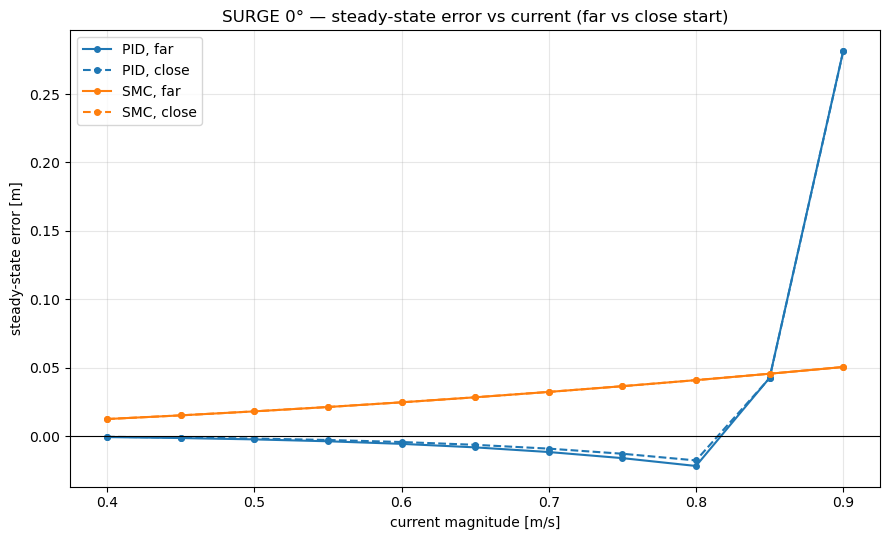

In [13]:
# =============================================================================
# SOGLIA DI ROTTURA PID: sweep completo, solo surge 0°, far vs close
# =============================================================================

x_ref, y_ref = 0.9, 0.0
dir_deg = 0.0
magnitudes_break = np.arange(0.4, 0.95, 0.05)

rows = []
for ctrl_name, gains in [('pid', gains_pid), ('smc', gains_smc)]:
    for x0_val, start_label in [(0.0, 'far'), (0.7, 'close')]:
        for mag in magnitudes_break:
            res = run_simulation(
                ctrl_name, x_ref=x_ref, y_ref=y_ref, psi_ref=0.0,
                x0=x0_val, y0=0.0,
                current_magnitude=mag, current_direction_deg=dir_deg,
                gains=gains, duration=60.0
            )
            steady_err = res['x'][-1] - x_ref
            rows.append({
                'controller': ctrl_name, 'start': start_label,
                'current_mag': round(mag, 2), 'steady_state_error': steady_err,
            })

df_break = pd.DataFrame(rows)

# --- grafico: steady-state error vs corrente, far vs close, PID vs SMC ---
fig, ax = plt.subplots(figsize=(9, 5.5))

for ctrl_name, color in [('pid', 'tab:blue'), ('smc', 'tab:orange')]:
    for start_label, style in [('far', '-'), ('close', '--')]:
        sub = df_break[(df_break['controller'] == ctrl_name) & (df_break['start'] == start_label)]
        ax.plot(sub['current_mag'], sub['steady_state_error'], style,
                color=color, marker='o', markersize=4,
                label=f'{ctrl_name.upper()}, {start_label}')

ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('current magnitude [m/s]'); ax.set_ylabel('steady-state error [m]')
ax.set_title('SURGE 0° — steady-state error vs current (far vs close start)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pid_break_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

## PID break threshold: far vs close (0.4–0.9 m/s, surge 0°)

Zooming into the 0.4–0.9 m/s range confirms the break threshold does **not**
meaningfully shift with the starting position: both `far` and `close` curves
overlap almost perfectly up to ~0.85 m/s, then diverge sharply at the same
point (0.85–0.9 m/s), where steady-state error jumps from near-zero to
~0.28 m for far / ~0.045 m for close — the same abrupt transition, just
slightly less severe when starting closer. SMC, by contrast, grows smoothly
and linearly across the whole range, staying an order of magnitude below
PID's error even at the edge of the tested window.

**Takeaway**: the PID failure threshold is a property of the disturbance
relative to the actuator/gain limits, not of the initial condition — starting
closer barely delays or softens the onset of the breakdown, it doesn't move
it to a meaningfully higher current magnitude.